# Bank Term Deposit Subscription Prediction

## 1. Problem Framing

### Business Problem

Banks run direct marketing campaigns to promote term deposit products, but not every contacted customer is equally likely to subscribe.

The goal of this project is to build a binary classification model that predicts whether a bank customer is likely to subscribe to a term deposit.

The model is intended to support marketing teams in prioritizing customer outreach and understanding subscription likelihood.

### Prediction Timing

Predictions are assumed to be made immediately before a marketing contact, using only information that would reasonably be available at that time.

This timing is important because features that become available only during or after the contact must not be used in the final predictive model.

### Target Variable

The target variable is `y`:

- `yes` — the customer subscribed to a term deposit.
- `no` — the customer did not subscribe.

The positive class is `yes`.

### Intended Use

The model is intended as a decision-support tool for campaign prioritization and analysis.

It should not be used to:

- determine eligibility for financial products,
- automatically exclude customers from receiving offers,
- make lending or credit decisions,
- replace human decision-making.

### Prediction Errors

A **false positive** occurs when the model predicts that a customer will subscribe, but the customer does not. This may result in unnecessary marketing effort.

A **false negative** occurs when the model predicts that a customer will not subscribe, but the customer actually would. This may cause a potentially interested customer to be deprioritized.

These trade-offs will be considered when defining the evaluation strategy.

## 2. Evaluation Strategy

### Primary Metric

The primary evaluation metric will be **Average Precision (AP)**.

The positive class represents customers who subscribe to the term deposit. Because this class is less frequent than the non-subscription class, accuracy alone may provide a misleading view of model quality.

Average Precision summarizes the precision-recall trade-off across decision thresholds and provides a more informative measure of how effectively the model identifies potential subscribers.

### Secondary Metrics

The following metrics will also be reported:

- **Precision** — measures how many customers predicted to subscribe actually subscribe.
- **Recall** — measures how many actual subscribers are successfully identified.
- **F1-score** — summarizes the balance between precision and recall.
- **ROC-AUC** — measures the model's overall ability to rank subscribers above non-subscribers.
- **Confusion Matrix** — shows the number of true positives, true negatives, false positives, and false negatives.

Accuracy may be reported for context but will not be used as the main model-selection metric.

### Validation Strategy

The full dataset is ordered chronologically from May 2008 to November 2010.

To better represent deployment on future marketing campaigns, the data will therefore not be randomly shuffled before the final split.

The earliest 80% of observations will be used as the training and development set, while the latest 20% will be reserved as an out-of-time test set.

Within the training data, time-aware cross-validation will be used for model comparison and hyperparameter tuning.

This strategy reduces the risk of training on future economic conditions when evaluating predictions for earlier periods.

The held-out test set will not be used for model selection, hyperparameter tuning, or threshold selection.

### Model Selection

Models will primarily be compared using cross-validated Average Precision. Precision, recall, F1-score, ROC-AUC, and variation across validation folds will be used as supporting evidence.

Decision-threshold analysis will be performed later using validation data rather than the held-out test set.

## 3. Data Understanding and Quality Audit

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "bank-additional-full.csv"

df = pd.read_csv(DATA_PATH, sep=";")

In [2]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 41188
Columns: 21


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [5]:
target_counts = df["y"].value_counts()
target_percentages = df["y"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

target_summary

,count,percentage
y,,
no,36548,88.734583
yes,4640,11.265417


In [6]:
missing_values = df.isna().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [16]:
categorical_columns = (
    df.drop(columns="y")
    .select_dtypes(exclude=np.number)
    .columns
)
unknown_counts = {}

for column in categorical_columns:
    unknown_counts[column] = (df[column] == "unknown").sum()

unknown_summary = (
    pd.Series(unknown_counts)
    .sort_values(ascending=False)
    .to_frame("unknown_count")
)

unknown_summary["percentage"] = (
    unknown_summary["unknown_count"] / len(df) * 100
)

unknown_summary

,unknown_count,percentage
default,8597,20.872584
education,1731,4.202680
housing,990,2.403613
loan,990,2.403613
job,330,0.801204
marital,80,0.194231
contact,0,0.000000
month,0,0.000000
day_of_week,0,0.000000
poutcome,0,0.000000


In [8]:
duplicate_count = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round(duplicate_count / len(df) * 100, 4),
    "%"
)

Exact duplicate rows: 12
Duplicate percentage: 0.0291 %


In [9]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
ce

In [10]:
df.nunique().sort_values()

contact              2
y                    2
default              3
loan                 3
poutcome             3
housing              3
marital              4
day_of_week          5
previous             8
education            8
emp.var.rate        10
month               10
nr.employed         11
job                 12
cons.price.idx      26
cons.conf.idx       26
pdays               27
campaign            42
age                 78
euribor3m          316
duration          1544
dtype: int64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [12]:
df["pdays"].value_counts().sort_index()

pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64

In [13]:
print(
    "pdays = 999:",
    (df["pdays"] == 999).sum()
)

pdays = 999: 39673


In [14]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    print(
        f"{column:20s}",
        "min =", df[column].min(),
        "max =", df[column].max()
    )

age                  min = 17 max = 98
duration             min = 0 max = 4918
campaign             min = 1 max = 56
pdays                min = 0 max = 999
previous             min = 0 max = 7
emp.var.rate         min = -3.4 max = 1.4
cons.price.idx       min = 92.201 max = 94.767
cons.conf.idx        min = -50.8 max = -26.9
euribor3m            min = 0.634 max = 5.045
nr.employed          min = 4963.6 max = 5228.1


### Feature Groups

**Customer characteristics**
- `age`
- `job`
- `marital`
- `education`
- `default`
- `housing`
- `loan`

**Current campaign information**
- `contact`
- `month`
- `day_of_week`
- `duration`
- `campaign`

**Previous campaign information**
- `pdays`
- `previous`
- `poutcome`

**Economic context**
- `emp.var.rate`
- `cons.price.idx`
- `cons.conf.idx`
- `euribor3m`
- `nr.employed`

**Target**
- `y`

### Initial Data Quality Findings

- The dataset contains 41,188 observations and 21 columns.
- The target `y` is imbalanced: approximately 88.7% non-subscribers and 11.3% subscribers.
- No conventional null values are present.
- Several categorical features contain an explicit `unknown` category, especially `default`.
- Twelve exact duplicate rows were identified.
- `pdays = 999` is a documented sentinel value. However, its relationship with `previous` and `poutcome` is not completely consistent in the observed data, so it will be handled cautiously during preprocessing.
- Several categorical variables have low-to-moderate cardinality.
- The `default` feature is highly imbalanced, with only three `yes` observations.
- Numerical ranges were inspected, but no outlier-removal decisions have been made at this stage.

## 4. Leakage Audit

The model is intended to make a prediction immediately before a specific marketing contact is made.

At prediction time, customer information, previous campaign history, the planned contact method, the date of contact, and current economic indicators are assumed to be available.

Information that becomes known only during or after the current contact must not be used in the final model.

### Main Leakage Risk: `duration`

The `duration` feature represents the duration of the last contact in seconds.

According to the dataset documentation, this feature strongly affects the target but is not known before the call is performed. After the call ends, the subscription outcome is also already known.

Therefore, `duration` will be excluded from the realistic predictive model because using it would introduce target-time leakage.

### Other Features

The variables `pdays`, `previous`, and `poutcome` describe previous campaign activity and are considered historical information available before the current contact.

The `campaign` variable records the number of contacts performed during the current campaign, including the current contact. It will be retained under the assumption that the prediction is made immediately before a specific contact attempt, when the number of that attempt is already known.

The economic indicators are also retained because they describe the economic conditions at the time of the campaign.

Because the full dataset is ordered chronologically, the validation strategy will preserve temporal ordering to avoid evaluating earlier observations using models trained on later economic conditions.

In [15]:
TARGET = "y"

LEAKAGE_FEATURES = [
    "duration"
]

FEATURES = [
    column
    for column in df.columns
    if column not in LEAKAGE_FEATURES + [TARGET]
]

print("Target:", TARGET)
print("Excluded leakage features:", LEAKAGE_FEATURES)
print("Number of model features:", len(FEATURES))
print("\nModel features:")
print(FEATURES)

Target: y
Excluded leakage features: ['duration']
Number of model features: 19

Model features:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


### Leakage Audit Decision

After reviewing the prediction timing and feature definitions:

- `duration` will be excluded from all realistic model-training and evaluation pipelines because it is not available before the current call is performed.
- `campaign` will be retained under the documented assumption that the prediction is made immediately before the current contact attempt.
- Previous campaign variables will be retained because they describe historical information.
- Economic indicators will be retained because they describe conditions available at the time of contact.
- The original dataframe will remain unchanged; the approved feature list will be used when constructing the modeling dataset.

The final realistic model will therefore use 19 input features.

## 5. Exploratory Data Analysis

Exploratory analysis will be performed on the development portion of the dataset only.

The final 20% of chronologically ordered observations will be reserved as an out-of-time test set and will not be inspected during exploratory analysis or model development.

The EDA will focus on:

- target-class imbalance,
- customer and campaign characteristics associated with subscription,
- previous campaign behavior,
- numerical feature distributions,
- relationships among economic indicators,
- unusual or low-frequency feature values.

No feature-removal or transformation decisions will be made solely from visual inspection at this stage.

In [17]:
SPLIT_RATIO = 0.80
split_index = int(len(df) * SPLIT_RATIO)

dev_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Development rows:", len(dev_df))
print("Held-out test rows:", len(test_df))
print("Total rows:", len(dev_df) + len(test_df))

Development rows: 32950
Held-out test rows: 8238
Total rows: 41188


In [24]:
import matplotlib.pyplot as plt

dev_target_summary = pd.DataFrame({
    "count": dev_df["y"].value_counts(),
    "percentage": dev_df["y"].value_counts(normalize=True) * 100
})

dev_target_summary

,count,percentage
y,,
no,30850,93.626707
yes,2100,6.373293


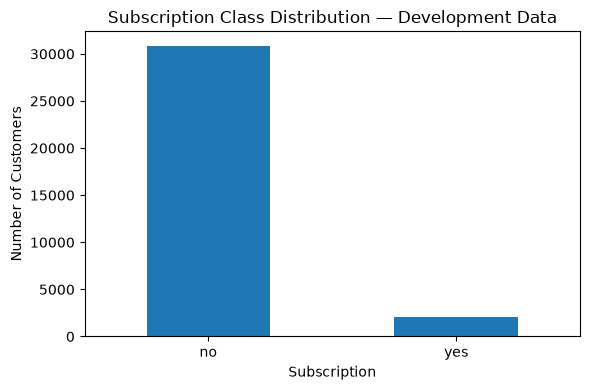

In [ ]:
ax = dev_df["y"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

ax.set_title("Subscription Class Distribution — Development Data")
ax.set_xlabel("Subscription")
ax.set_ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
def category_subscription_summary(data, column):
    summary = (
        data.groupby(column)
        .agg(
            customers=("y", "size"),
            subscribers=("y", lambda values: (values == "yes").sum())
        )
    )

    summary["subscription_rate"] = (
        summary["subscribers"] / summary["customers"]
    )

    return summary.sort_values(
        "subscription_rate",
        ascending=False
    )

In [21]:
poutcome_summary = category_subscription_summary(
    dev_df,
    "poutcome"
)

poutcome_summary

,customers,subscribers,subscription_rate
poutcome,,,
success,168,63,0.375000
nonexistent,30675,1912,0.062331
failure,2107,125,0.059326


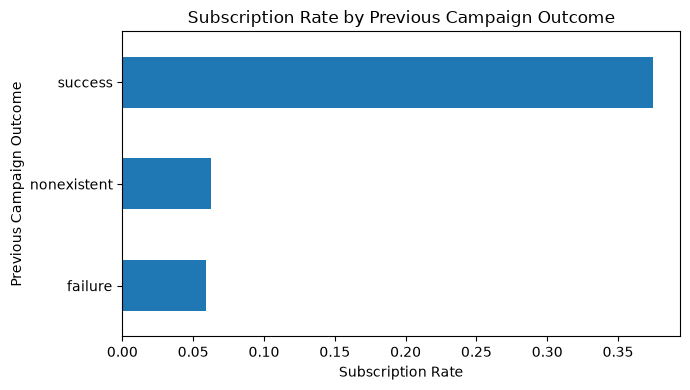

In [22]:
ax = (
    poutcome_summary["subscription_rate"]
    .sort_values()
    .plot(
        kind="barh",
        figsize=(7, 4)
    )
)

ax.set_title("Subscription Rate by Previous Campaign Outcome")
ax.set_xlabel("Subscription Rate")
ax.set_ylabel("Previous Campaign Outcome")

plt.tight_layout()
plt.show()

In [25]:
contact_summary = category_subscription_summary(
    dev_df,
    "contact"
)

contact_summary

,customers,subscribers,subscription_rate
contact,,,
cellular,18899,1521,0.080480
telephone,14051,579,0.041207


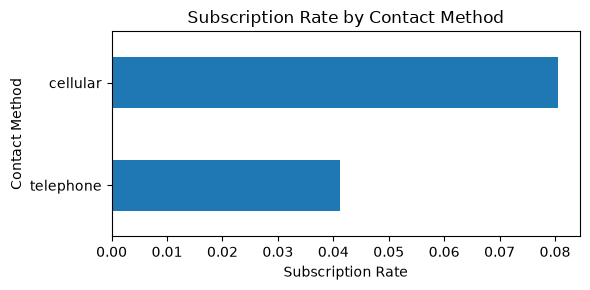

In [26]:
ax = (
    contact_summary["subscription_rate"]
    .sort_values()
    .plot(
        kind="barh",
        figsize=(6, 3)
    )
)

ax.set_title("Subscription Rate by Contact Method")
ax.set_xlabel("Subscription Rate")
ax.set_ylabel("Contact Method")

plt.tight_layout()
plt.show()

In [27]:
month_summary = category_subscription_summary(
    dev_df,
    "month"
)

month_summary

,customers,subscribers,subscription_rate
month,,,
oct,67,42,0.626866
mar,282,126,0.446809
apr,2458,442,0.179821
dec,10,1,0.100000
jul,6685,407,0.060883
nov,3616,190,0.052544
aug,5175,271,0.052367
jun,4374,188,0.042981
may,10283,433,0.042108


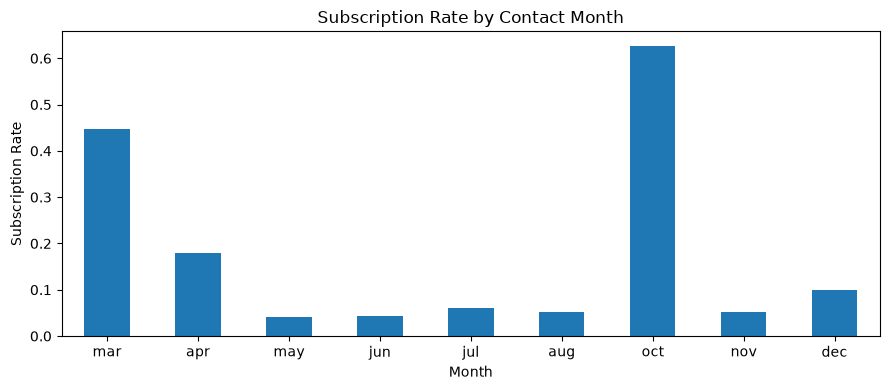

In [28]:
month_order = [
    "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct",
    "nov", "dec"
]

month_rates = (
    month_summary
    .reindex(month_order)
    ["subscription_rate"]
    .dropna()
)

ax = month_rates.plot(
    kind="bar",
    figsize=(9, 4)
)

ax.set_title("Subscription Rate by Contact Month")
ax.set_xlabel("Month")
ax.set_ylabel("Subscription Rate")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
job_summary = category_subscription_summary(
    dev_df,
    "job"
)

job_summary

,customers,subscribers,subscription_rate
job,,,
student,347,60,0.172911
retired,990,113,0.114141
self-employed,1156,81,0.070069
admin.,8040,558,0.069403
management,2400,159,0.066250
technician,5577,353,0.063296
entrepreneur,1261,79,0.062649
unemployed,749,43,0.057410
unknown,266,15,0.056391


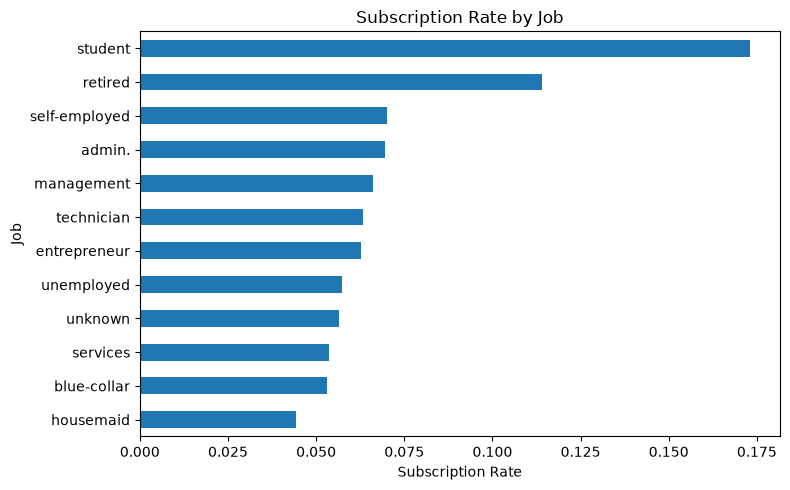

In [30]:
ax = (
    job_summary["subscription_rate"]
    .sort_values()
    .plot(
        kind="barh",
        figsize=(8, 5)
    )
)

ax.set_title("Subscription Rate by Job")
ax.set_xlabel("Subscription Rate")
ax.set_ylabel("Job")

plt.tight_layout()
plt.show()

In [31]:
default_summary = category_subscription_summary(
    dev_df,
    "default"
)

default_summary

,customers,subscribers,subscription_rate
default,,,
no,24930,1753,0.070317
unknown,8017,347,0.043283
yes,3,0,0.000000


In [32]:
approved_numeric_features = (
    dev_df[FEATURES]
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

approved_numeric_features

['age',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [33]:
numeric_medians_by_target = (
    dev_df.groupby("y")[approved_numeric_features]
    .median()
    .T
)

numeric_medians_by_target

y,no,yes
age,39.000,37.000
campaign,2.000,2.000
pdays,999.000,999.000
previous,0.000,0.000
emp.var.rate,1.100,1.100
cons.price.idx,93.918,93.444
cons.conf.idx,-41.800,-42.700
euribor3m,4.864,4.857
nr.employed,5195.800,5195.800


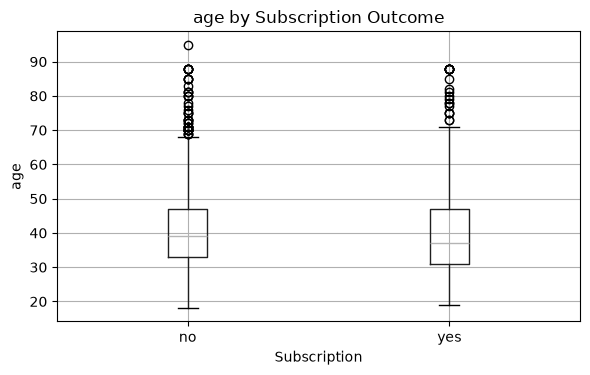

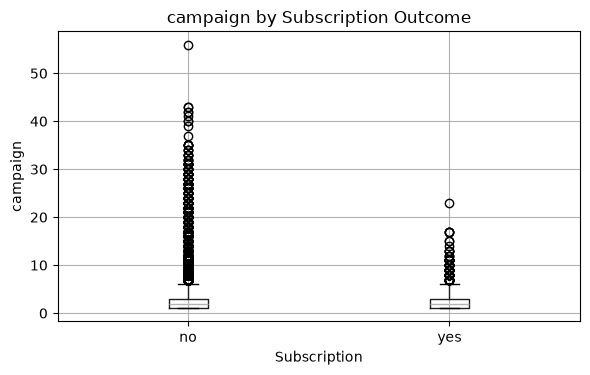

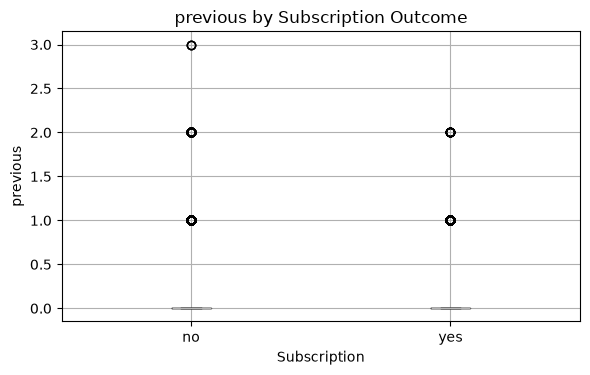

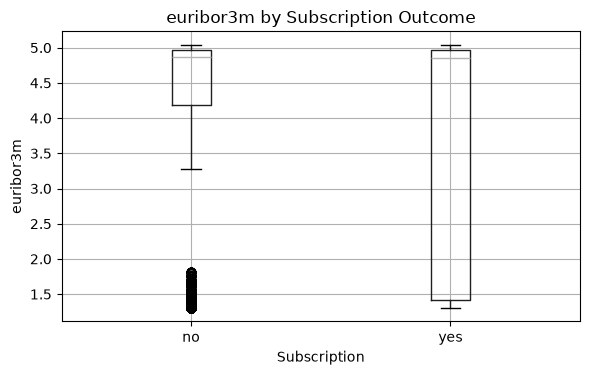

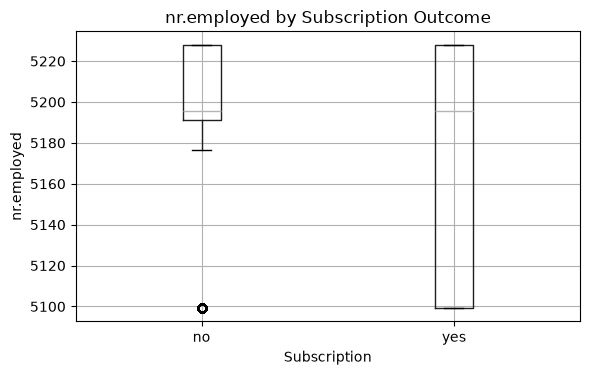

In [34]:
selected_numeric_features = [
    "age",
    "campaign",
    "previous",
    "euribor3m",
    "nr.employed"
]

for column in selected_numeric_features:
    ax = dev_df.boxplot(
        column=column,
        by="y",
        figsize=(6, 4)
    )

    ax.set_title(f"{column} by Subscription Outcome")
    ax.set_xlabel("Subscription")
    ax.set_ylabel(column)

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

In [35]:
numeric_correlation = (
    dev_df[approved_numeric_features]
    .corr()
)

numeric_correlation.round(2)

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.00,0.02,-0.01,0.00,0.03,0.00,0.07,0.04,0.03
campaign,0.02,1.00,0.02,-0.07,0.14,0.14,0.03,0.12,0.14
pdays,-0.01,0.02,1.00,-0.28,0.13,0.10,0.10,0.13,0.12
previous,0.00,-0.07,-0.28,1.00,-0.44,-0.37,-0.31,-0.43,-0.39
emp.var.rate,0.03,0.14,0.13,-0.44,1.00,0.78,0.69,0.98,0.95
cons.price.idx,0.00,0.14,0.10,-0.37,0.78,1.00,0.37,0.74,0.66
cons.conf.idx,0.07,0.03,0.10,-0.31,0.69,0.37,1.00,0.72,0.55
euribor3m,0.04,0.12,0.13,-0.43,0.98,0.74,0.72,1.00,0.95
nr.employed,0.03,0.14,0.12,-0.39,0.95,0.66,0.55,0.95,1.00


In [36]:
upper_triangle = numeric_correlation.where(
    np.triu(
        np.ones(numeric_correlation.shape),
        k=1
    ).astype(bool)
)

strongest_correlations = (
    upper_triangle
    .stack()
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
    .head(10)
)

strongest_correlations.to_frame("correlation")

correlation
emp.var.rate   euribor3m          0.977621
euribor3m      nr.employed        0.951532
emp.var.rate   nr.employed        0.946403
               cons.price.idx     0.780208
cons.price.idx euribor3m          0.735253
cons.conf.idx  euribor3m          0.716260
emp.var.rate   cons.conf.idx      0.688109
cons.price.idx nr.employed        0.662134
cons.conf.idx  nr.employed        0.549268
previous       emp.var.rate      -0.441295

In [39]:
previous_contact_summary = (
    dev_df
    .assign(
        had_previous_contacts=lambda data:
            data["previous"] > 0
    )
    .groupby("had_previous_contacts")
    .agg(
        customers=("y", "size"),
        subscribers=("y", lambda values: (values == "yes").sum())
    )
)

previous_contact_summary["subscription_rate"] = (
    previous_contact_summary["subscribers"]
    / previous_contact_summary["customers"]
)

previous_contact_summary

,customers,subscribers,subscription_rate
had_previous_contacts,,,
False,30675,1912,0.062331
True,2275,188,0.082637


In [40]:
pd.crosstab(
    dev_df["previous"] > 0,
    dev_df["pdays"] == 999,
    rownames=["Previous contacts > 0"],
    colnames=["pdays = 999"]
)

pdays = 999,False,True
Previous contacts > 0,,
False,0,30675
True,174,2101


### EDA Findings

The exploratory analysis revealed several patterns that will guide the modeling stage:

- The development dataset is strongly imbalanced, with 2,100 subscribers out of 32,950 observations (approximately 6.37% positive cases). This reinforces the decision to avoid accuracy as the primary model-selection metric.

- Previous campaign outcome shows a strong descriptive relationship with subscription. Customers whose previous campaign outcome was `success` had a subscription rate of approximately 37.5%, compared with around 6% for `failure` and `nonexistent`. However, the successful-outcome group contains only 168 development observations, so this result should be interpreted cautiously.

- Customers contacted through `cellular` communication had a higher observed subscription rate (approximately 8.05%) than customers contacted by `telephone` (approximately 4.12%).

- Subscription rates varied substantially across contact months. Some months, particularly March and October, showed high observed rates, but several of these groups contain relatively few observations. These differences may also reflect changing campaign or economic conditions over time and should not be interpreted as causal effects of the month itself.

- Student and retired customer groups showed relatively high observed subscription rates compared with several other job categories. These results are descriptive associations and do not imply that occupation causes subscription behavior.

- The `default = yes` category contains only three observations in the development data and therefore provides insufficient evidence for meaningful conclusions about that category.

- Median values of several numerical variables are similar across the two target classes, suggesting that simple univariate numerical differences alone may not provide strong class separation.

- Several economic indicators are highly correlated. In particular, `emp.var.rate` and `euribor3m`, `euribor3m` and `nr.employed`, and `emp.var.rate` and `nr.employed` show correlations above 0.94. This will be considered when interpreting models, especially linear-model coefficients.

- Using `previous > 0` as the indicator of previous campaign contact, customers with previous contacts had an observed subscription rate of approximately 8.26%, compared with 6.23% for customers without previous contacts.

- The special value `pdays = 999` should not be interpreted as a simple binary indicator of whether a customer had previous contact. In the development data, 2,101 customers have `previous > 0` while also having `pdays = 999`. Its treatment will therefore be considered carefully during preprocessing.

These observations are exploratory associations only. No feature will be removed or retained solely because of these univariate patterns, and no causal conclusions are drawn from the analysis.

## 6. Data Cleaning and Preprocessing

The preprocessing strategy is designed to remain reproducible and compatible with cross-validation.

### Cleaning Decisions

- The leakage feature `duration` will not be included in the modeling feature set.
- The explicit `unknown` values in categorical variables will be retained as their own category rather than being treated as conventional missing values.
- Exact duplicate rows will be retained. Only a very small number were identified, and the dataset does not provide a unique customer or contact identifier that would allow them to be confidently classified as erroneous duplicate records.
- `pdays` will initially be treated as a categorical feature. The value `999` is a special sentinel value and does not behave like a normal numerical distance, so treating the entire variable as categorical avoids imposing an inappropriate linear numerical relationship.

### Transformation Strategy

Numerical variables will be standardized using `StandardScaler`.

Categorical variables will be encoded using one-hot encoding. Unknown categories encountered during validation or testing will be ignored rather than causing transformation errors.

All transformations will be placed inside a scikit-learn preprocessing pipeline so that preprocessing can later be fitted independently within each cross-validation fold.

In [41]:
X_dev = dev_df[FEATURES].copy()

y_dev = (
    dev_df[TARGET]
    .map({
        "no": 0,
        "yes": 1
    })
)

print("X_dev shape:", X_dev.shape)
print("y_dev shape:", y_dev.shape)

print("\nTarget mapping:")
print(y_dev.value_counts())

X_dev shape: (32950, 19)
y_dev shape: (32950,)

Target mapping:
y
0    30850
1     2100
Name: count, dtype: int64


In [42]:
print("Missing target values:", y_dev.isna().sum())

print(
    "duration in modeling features:",
    "duration" in X_dev.columns
)

print(
    "Target in modeling features:",
    TARGET in X_dev.columns
)

Missing target values: 0
duration in modeling features: False
Target in modeling features: False


In [43]:
NUMERIC_FEATURES = [
    "age",
    "campaign",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

CATEGORICAL_FEATURES = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome",
    "pdays"
]

print("Numerical features:", len(NUMERIC_FEATURES))
print("Categorical features:", len(CATEGORICAL_FEATURES))
print(
    "Total modeling features:",
    len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)
)

Numerical features: 8
Categorical features: 11
Total modeling features: 19


In [44]:
defined_features = set(
    NUMERIC_FEATURES + CATEGORICAL_FEATURES
)

expected_features = set(FEATURES)

print(
    "Missing from preprocessing:",
    expected_features - defined_features
)

print(
    "Unexpected preprocessing features:",
    defined_features - expected_features
)

print(
    "Duplicated between feature groups:",
    set(NUMERIC_FEATURES).intersection(
        CATEGORICAL_FEATURES
    )
)

Missing from preprocessing: set()
Unexpected preprocessing features: set()
Duplicated between feature groups: set()


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [46]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

numeric_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [47]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categor

In [48]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            NUMERIC_FEATURES
        ),
        (
            "cat",
            categorical_pipeline,
            CATEGORICAL_FEATURES
        )
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [49]:
from sklearn.base import clone

preview_preprocessor = clone(preprocessor)

X_dev_transformed = (
    preview_preprocessor
    .fit_transform(X_dev)
)

print(
    "Original shape:",
    X_dev.shape
)

print(
    "Transformed shape:",
    X_dev_transformed.shape
)

Original shape: (32950, 19)
Transformed shape: (32950, 74)


In [50]:
transformed_feature_names = (
    preview_preprocessor
    .get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(transformed_feature_names)
)

print("\nFirst 25 transformed features:")

for feature in transformed_feature_names[:25]:
    print(feature)

Number of transformed features: 74

First 25 transformed features:
num__age
num__campaign
num__previous
num__emp.var.rate
num__cons.price.idx
num__cons.conf.idx
num__euribor3m
num__nr.employed
cat__job_admin.
cat__job_blue-collar
cat__job_entrepreneur
cat__job_housemaid
cat__job_management
cat__job_retired
cat__job_self-employed
cat__job_services
cat__job_student
cat__job_technician
cat__job_unemployed
cat__job_unknown
cat__marital_divorced
cat__marital_married
cat__marital_single
cat__marital_unknown
cat__education_basic.4y


In [51]:
print(
    "NaN values after transformation:",
    np.isnan(X_dev_transformed).sum()
)

NaN values after transformation: 0


### Cross-Validation Safety

The fitted preprocessing object above is used only as a structural sanity check to verify that the transformations run successfully.

The transformed development matrix produced here will **not** be used directly for model comparison.

During modeling, the unfitted `preprocessor` will be placed inside a full scikit-learn `Pipeline` together with each estimator. This ensures that scaling and categorical encoding are learned separately from the training portion of each cross-validation split rather than from the entire development dataset.

The held-out test set has not been used to fit or inspect the preprocessing transformations.

### Preprocessing Decisions Summary

The final preprocessing design currently uses:

- **19 input features** after excluding `duration`.
- **8 numerical features**, standardized using `StandardScaler`.
- **11 categorical features**, encoded using `OneHotEncoder`.
- `unknown` values retained as explicit categories.
- `pdays` treated as categorical because of its special sentinel value and non-standard numerical semantics.
- Exact duplicate observations retained because there is insufficient evidence that they represent erroneous duplicate records.
- No conventional missing-value imputation is required.
- Preprocessing will be fitted inside each cross-validation fold through a complete model pipeline.

These decisions may be revisited only if later model diagnostics provide a clear, documented reason.

## 7. Baseline Model

Before training any predictive model, a simple baseline is established.

A `DummyClassifier` using the training-class prior will be used. This model does not learn relationships between customer features and subscription outcomes. Instead, it provides a reference level that the real machine-learning models must outperform.

The baseline will be evaluated using the same time-aware cross-validation folds and the same metrics that will later be used for all candidate models.

Because the positive-class prevalence changes across time periods, the validation positive rate will also be reported alongside Average Precision.

In [52]:
from sklearn.model_selection import TimeSeriesSplit

time_cv = TimeSeriesSplit(n_splits=5)

CV_SPLITS = list(
    time_cv.split(X_dev)
)

print("Number of CV folds:", len(CV_SPLITS))

Number of CV folds: 5


In [53]:
fold_overview = []

for fold_number, (train_idx, validation_idx) in enumerate(
    CV_SPLITS,
    start=1
):
    fold_overview.append({
        "fold": fold_number,
        "train_rows": len(train_idx),
        "validation_rows": len(validation_idx),
        "train_positive_rate": y_dev.iloc[train_idx].mean(),
        "validation_positive_rate": y_dev.iloc[validation_idx].mean()
    })

fold_overview = pd.DataFrame(fold_overview)

fold_overview

,fold,train_rows,validation_rows,train_positive_rate,validation_positive_rate
0,1,5495,5491,0.029299,0.038973
1,2,10986,5491,0.034134,0.060280
2,3,16477,5491,0.042848,0.059188
3,4,21968,5491,0.046932,0.054453
4,5,27459,5491,0.048436,0.140229


In [54]:
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)

SCORING = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "accuracy": "accuracy"
}

In [55]:
from sklearn.dummy import DummyClassifier

dummy_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DummyClassifier(
                strategy="prior"
            )
        )
    ]
)

dummy_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [56]:
from sklearn.model_selection import cross_validate

dummy_cv_raw = cross_validate(
    estimator=dummy_pipeline,
    X=X_dev,
    y=y_dev,
    cv=CV_SPLITS,
    scoring=SCORING,
    return_train_score=False
)

In [58]:
dummy_cv_raw.keys()

dict_keys(['fit_time', 'score_time', 'test_average_precision', 'test_roc_auc', 'test_precision', 'test_recall', 'test_f1', 'test_accuracy'])

In [59]:
dummy_cv_results = pd.DataFrame({
    "fold": range(1, len(CV_SPLITS) + 1),

    "validation_positive_rate":
        fold_overview["validation_positive_rate"],

    "average_precision":
        dummy_cv_raw["test_average_precision"],

    "roc_auc":
        dummy_cv_raw["test_roc_auc"],

    "precision":
        dummy_cv_raw["test_precision"],

    "recall":
        dummy_cv_raw["test_recall"],

    "f1":
        dummy_cv_raw["test_f1"],

    "accuracy":
        dummy_cv_raw["test_accuracy"]
})

dummy_cv_results

,fold,validation_positive_rate,average_precision,roc_auc,precision,recall,f1,accuracy
0,1,0.038973,0.038973,0.5,0.0,0.0,0.0,0.961027
1,2,0.060280,0.060280,0.5,0.0,0.0,0.0,0.939720
2,3,0.059188,0.059188,0.5,0.0,0.0,0.0,0.940812
3,4,0.054453,0.054453,0.5,0.0,0.0,0.0,0.945547
4,5,0.140229,0.140229,0.5,0.0,0.0,0.0,0.859771


In [60]:
baseline_metrics = [
    "average_precision",
    "roc_auc",
    "precision",
    "recall",
    "f1",
    "accuracy"
]

dummy_summary = (
    dummy_cv_results[baseline_metrics]
    .agg(["mean", "std"])
    .T
)

dummy_summary

,mean,std
average_precision,0.070625,0.039831
roc_auc,0.500000,0.000000
precision,0.000000,0.000000
recall,0.000000,0.000000
f1,0.000000,0.000000
accuracy,0.929375,0.039831


In [61]:
BASELINE_AP = dummy_cv_results[
    "average_precision"
].mean()

print(
    "Mean baseline Average Precision:",
    round(BASELINE_AP, 4)
)

Mean baseline Average Precision: 0.0706


In [62]:
baseline_comparison = dummy_cv_results[
    [
        "fold",
        "validation_positive_rate",
        "average_precision"
    ]
].copy()

baseline_comparison

,fold,validation_positive_rate,average_precision
0,1,0.038973,0.038973
1,2,0.060280,0.060280
2,3,0.059188,0.059188
3,4,0.054453,0.054453
4,5,0.140229,0.140229


### Baseline Interpretation

The `DummyClassifier` provides a no-skill reference for model evaluation.

Across the five time-aware validation folds, the baseline achieved a mean Average Precision of approximately **0.071** and a ROC-AUC of **0.50**, indicating no ability to distinguish subscribers from non-subscribers.

At the default classification threshold, the dummy model predicted no positive cases, resulting in:

- Precision = 0
- Recall = 0
- F1-score = 0

Despite this, the model achieved a mean accuracy of approximately **92.9%** because the majority of customers did not subscribe. This demonstrates why accuracy is misleading for this imbalanced classification problem.

Average Precision closely matched the positive-class prevalence within each validation fold, as expected from a model that provides no useful ranking information.

The validation positive rate also changed substantially across time. In particular, the final validation fold contained approximately **14.0%** subscribers, compared with roughly **4–6%** in the earlier folds. This indicates temporal variation in the target distribution and reinforces the use of time-aware validation.

Future models must therefore outperform the no-skill Average Precision baseline while also being evaluated for consistency across different time periods.